314. M. Binary Tree Vertical Order Traversal 

Given the root of a binary tree, return the vertical order traversal of its nodes' values. (i.e., from top to bottom, column by column).

If two nodes are in the same row and column, the order should be from left to right.

Example 1:
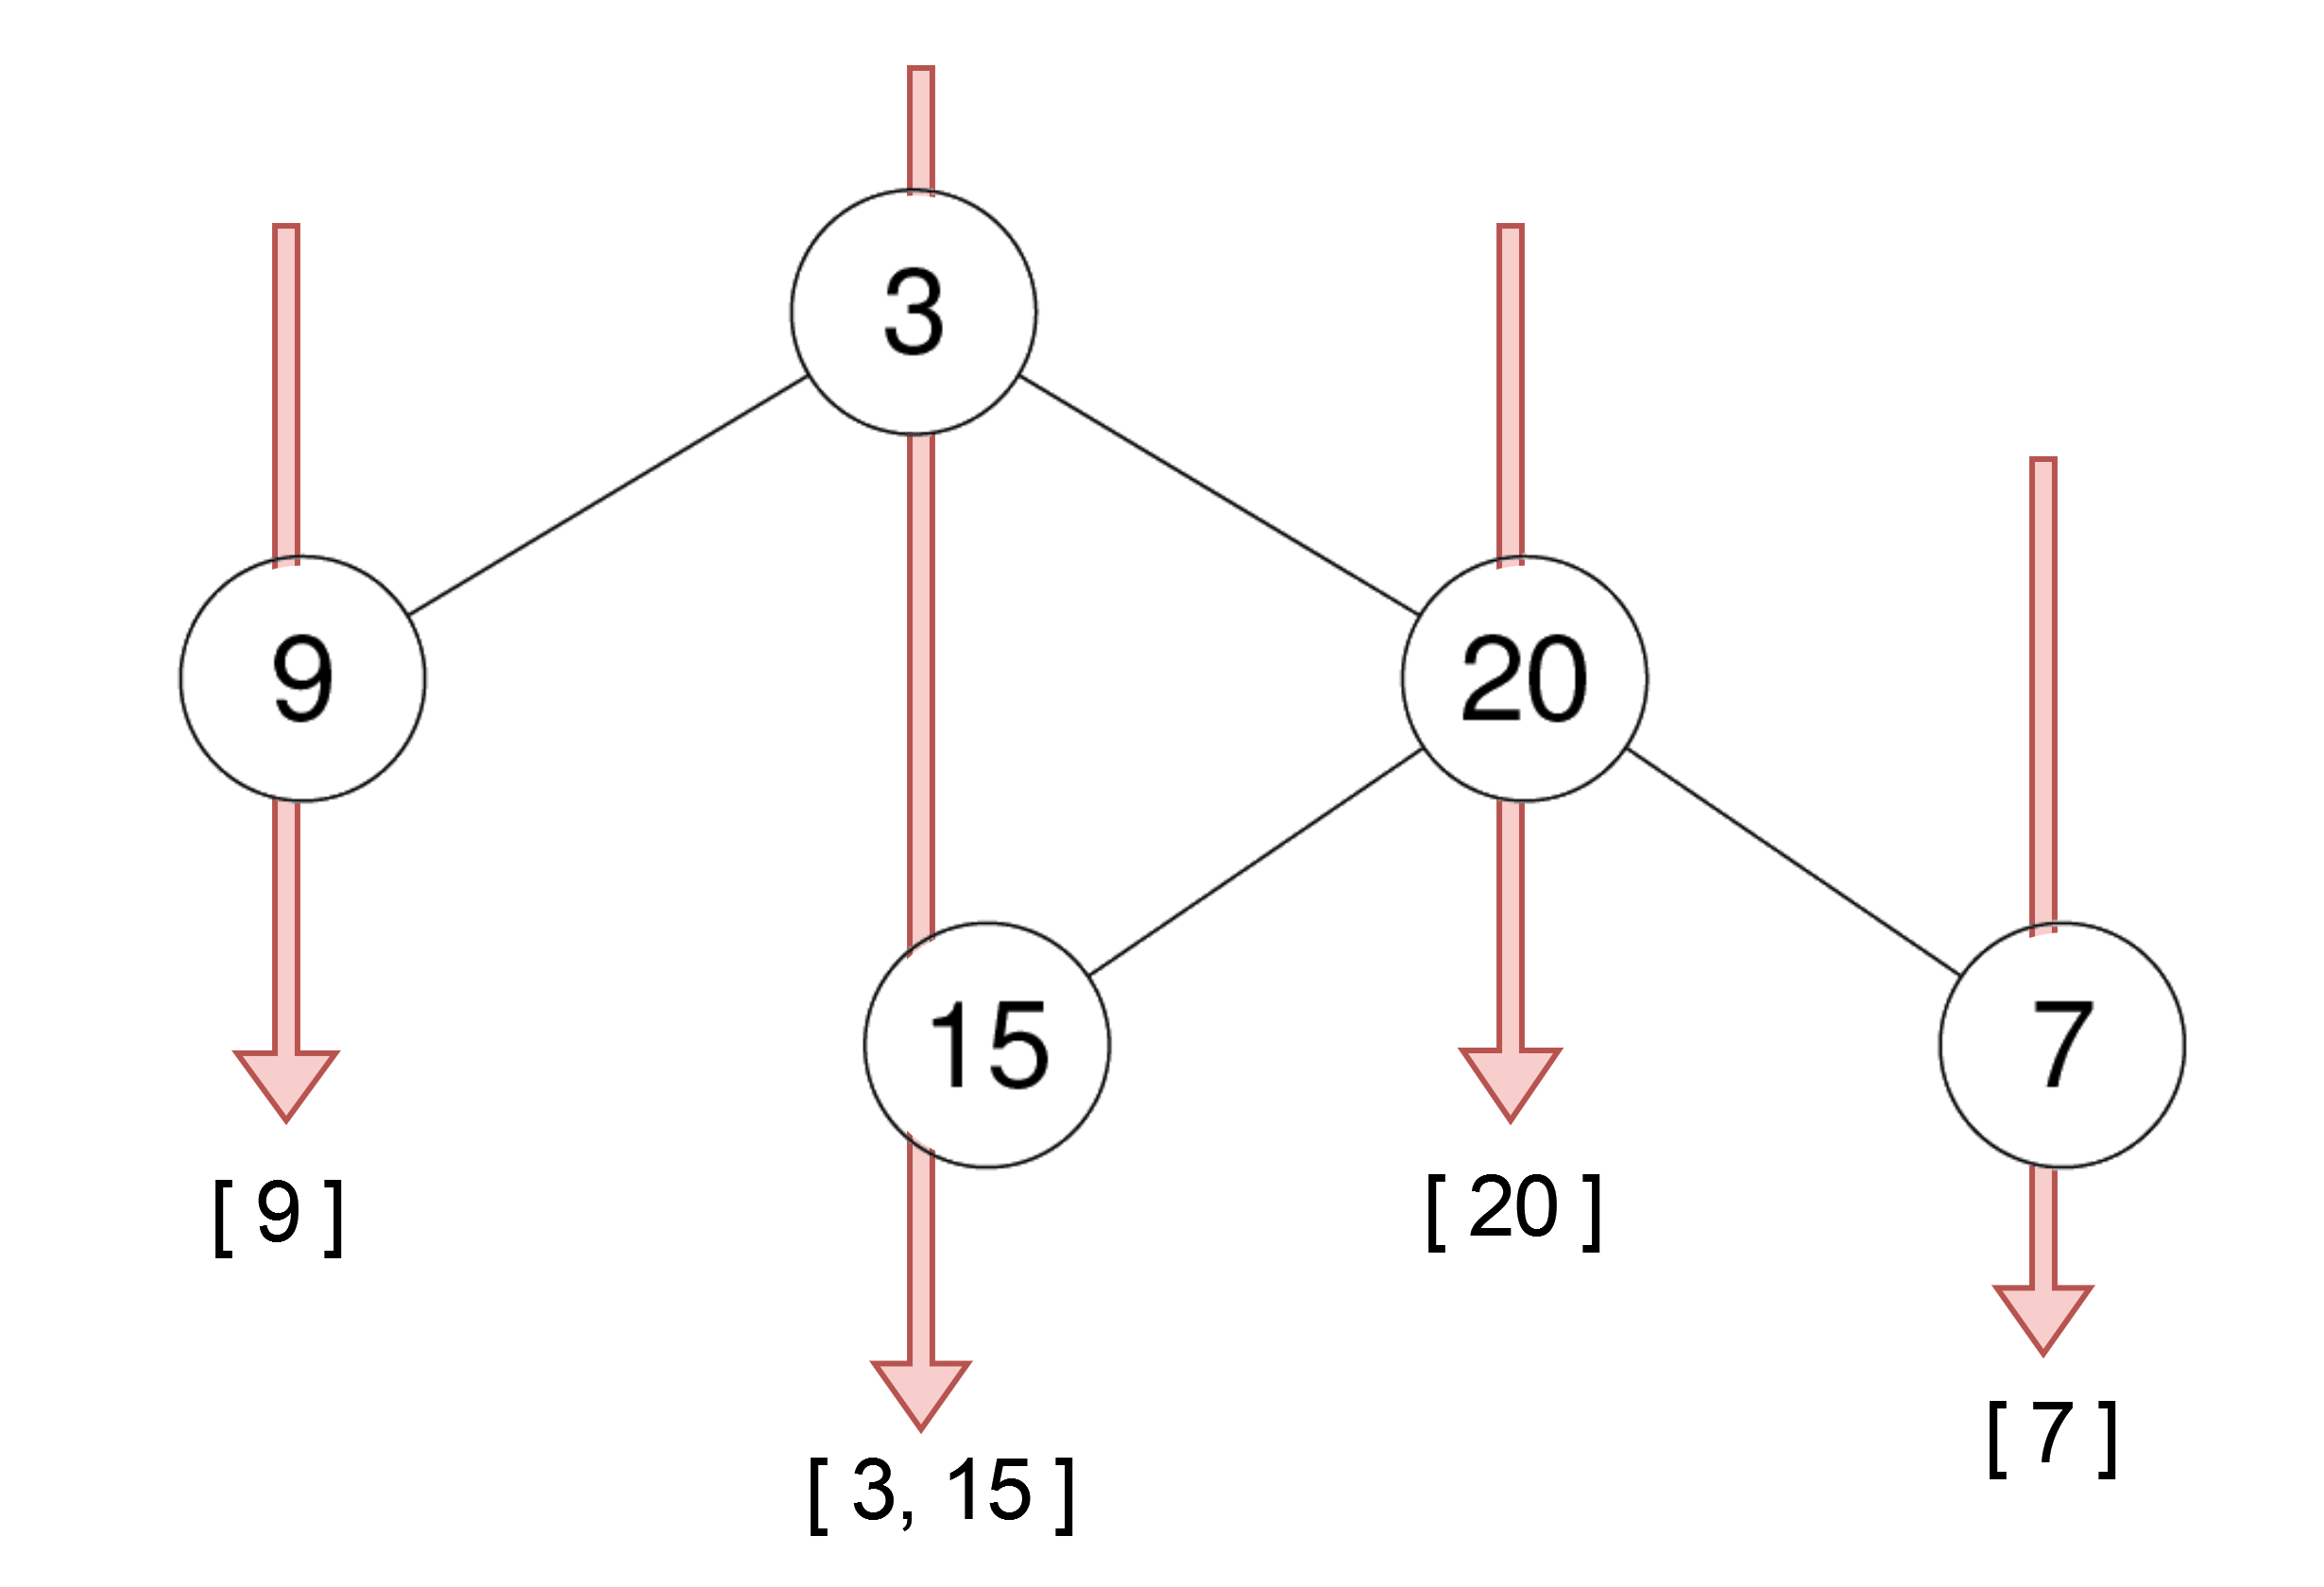

Input: root = [3,9,20,null,null,15,7]
Output: [[9],[3,15],[20],[7]]

Example2: 

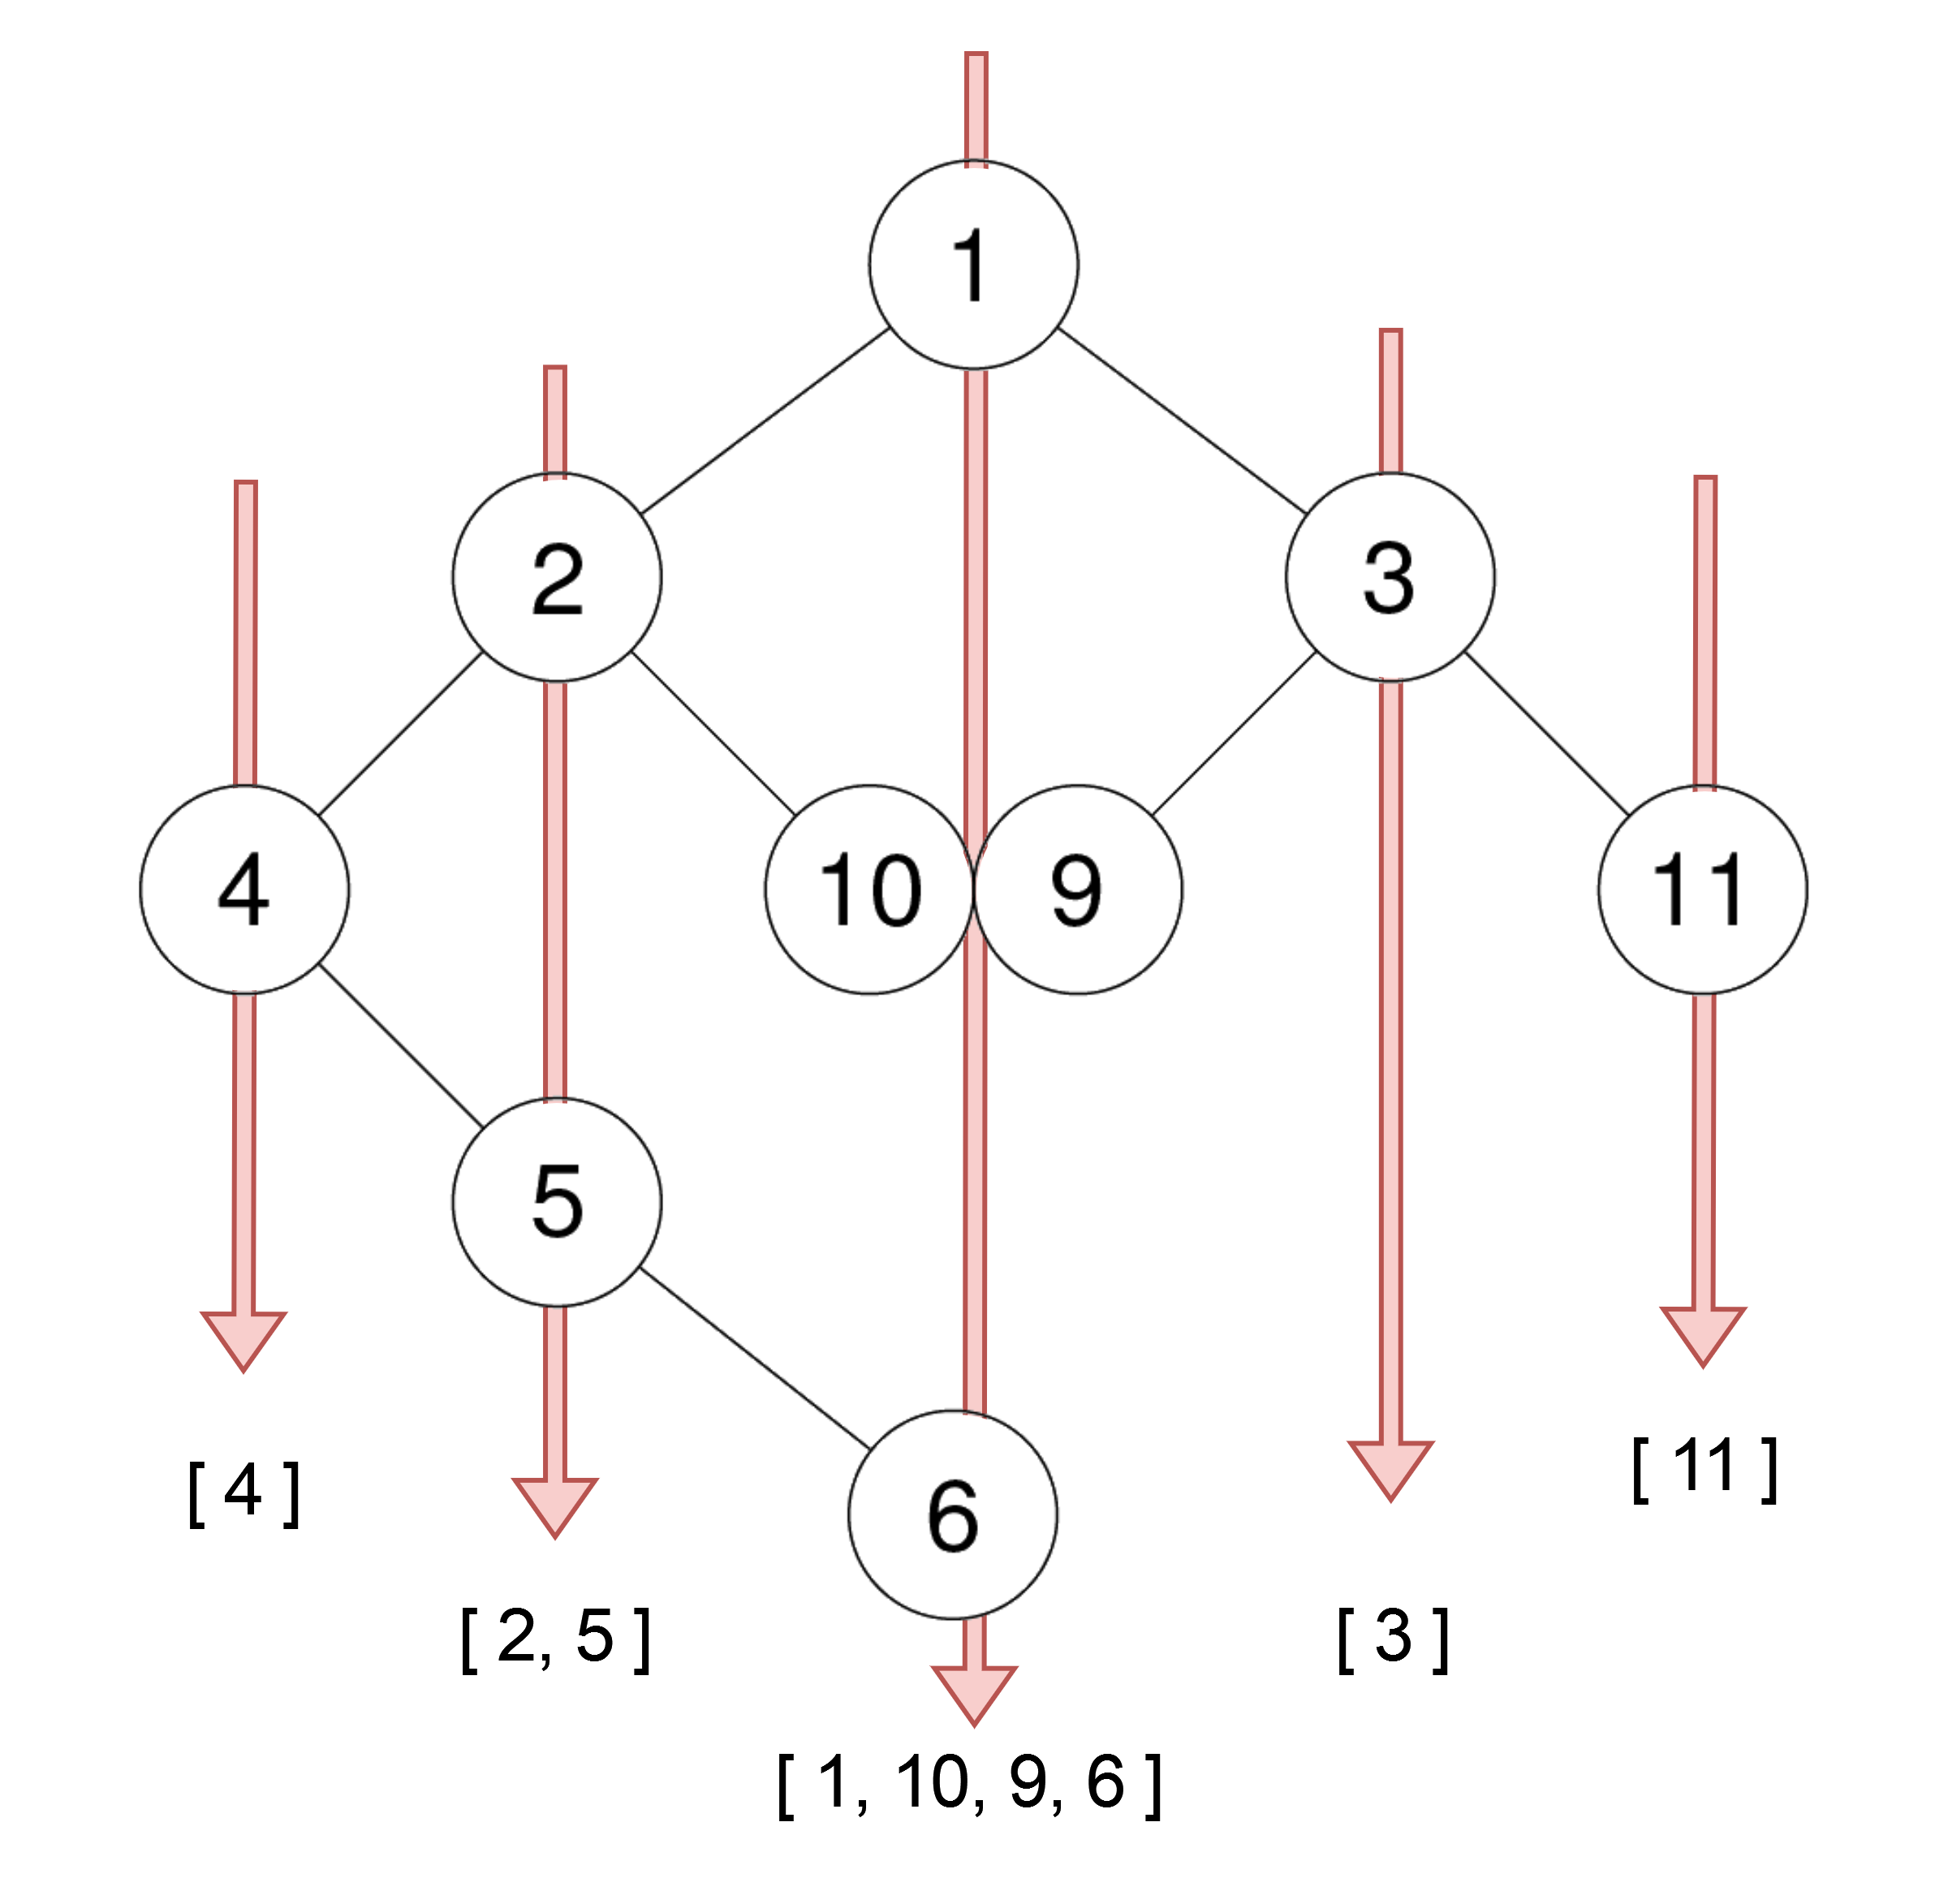

Input: root = [3,9,8,4,0,1,7]
Output: [[4],[9],[3,0,1],[8],[7]]


Hint:
1. Do BFS from the root. Let the root be at column 0. In the BFS, keep in the queue the node and its column.

2. When you traverse a node, store its value in the column index. For example, the root's value should be stored at index 0.

3. If the node has a left node, it column should be col - 1. Similarly, if the node has a right node, its column should be col + 1.

4. At the end, check the minimum and maximum col and output their values.


Constraints:
    1. Number of nodes in the tree [0, 100]

    2. Node value range: -100 <= node.val <= 100 

Example 3:

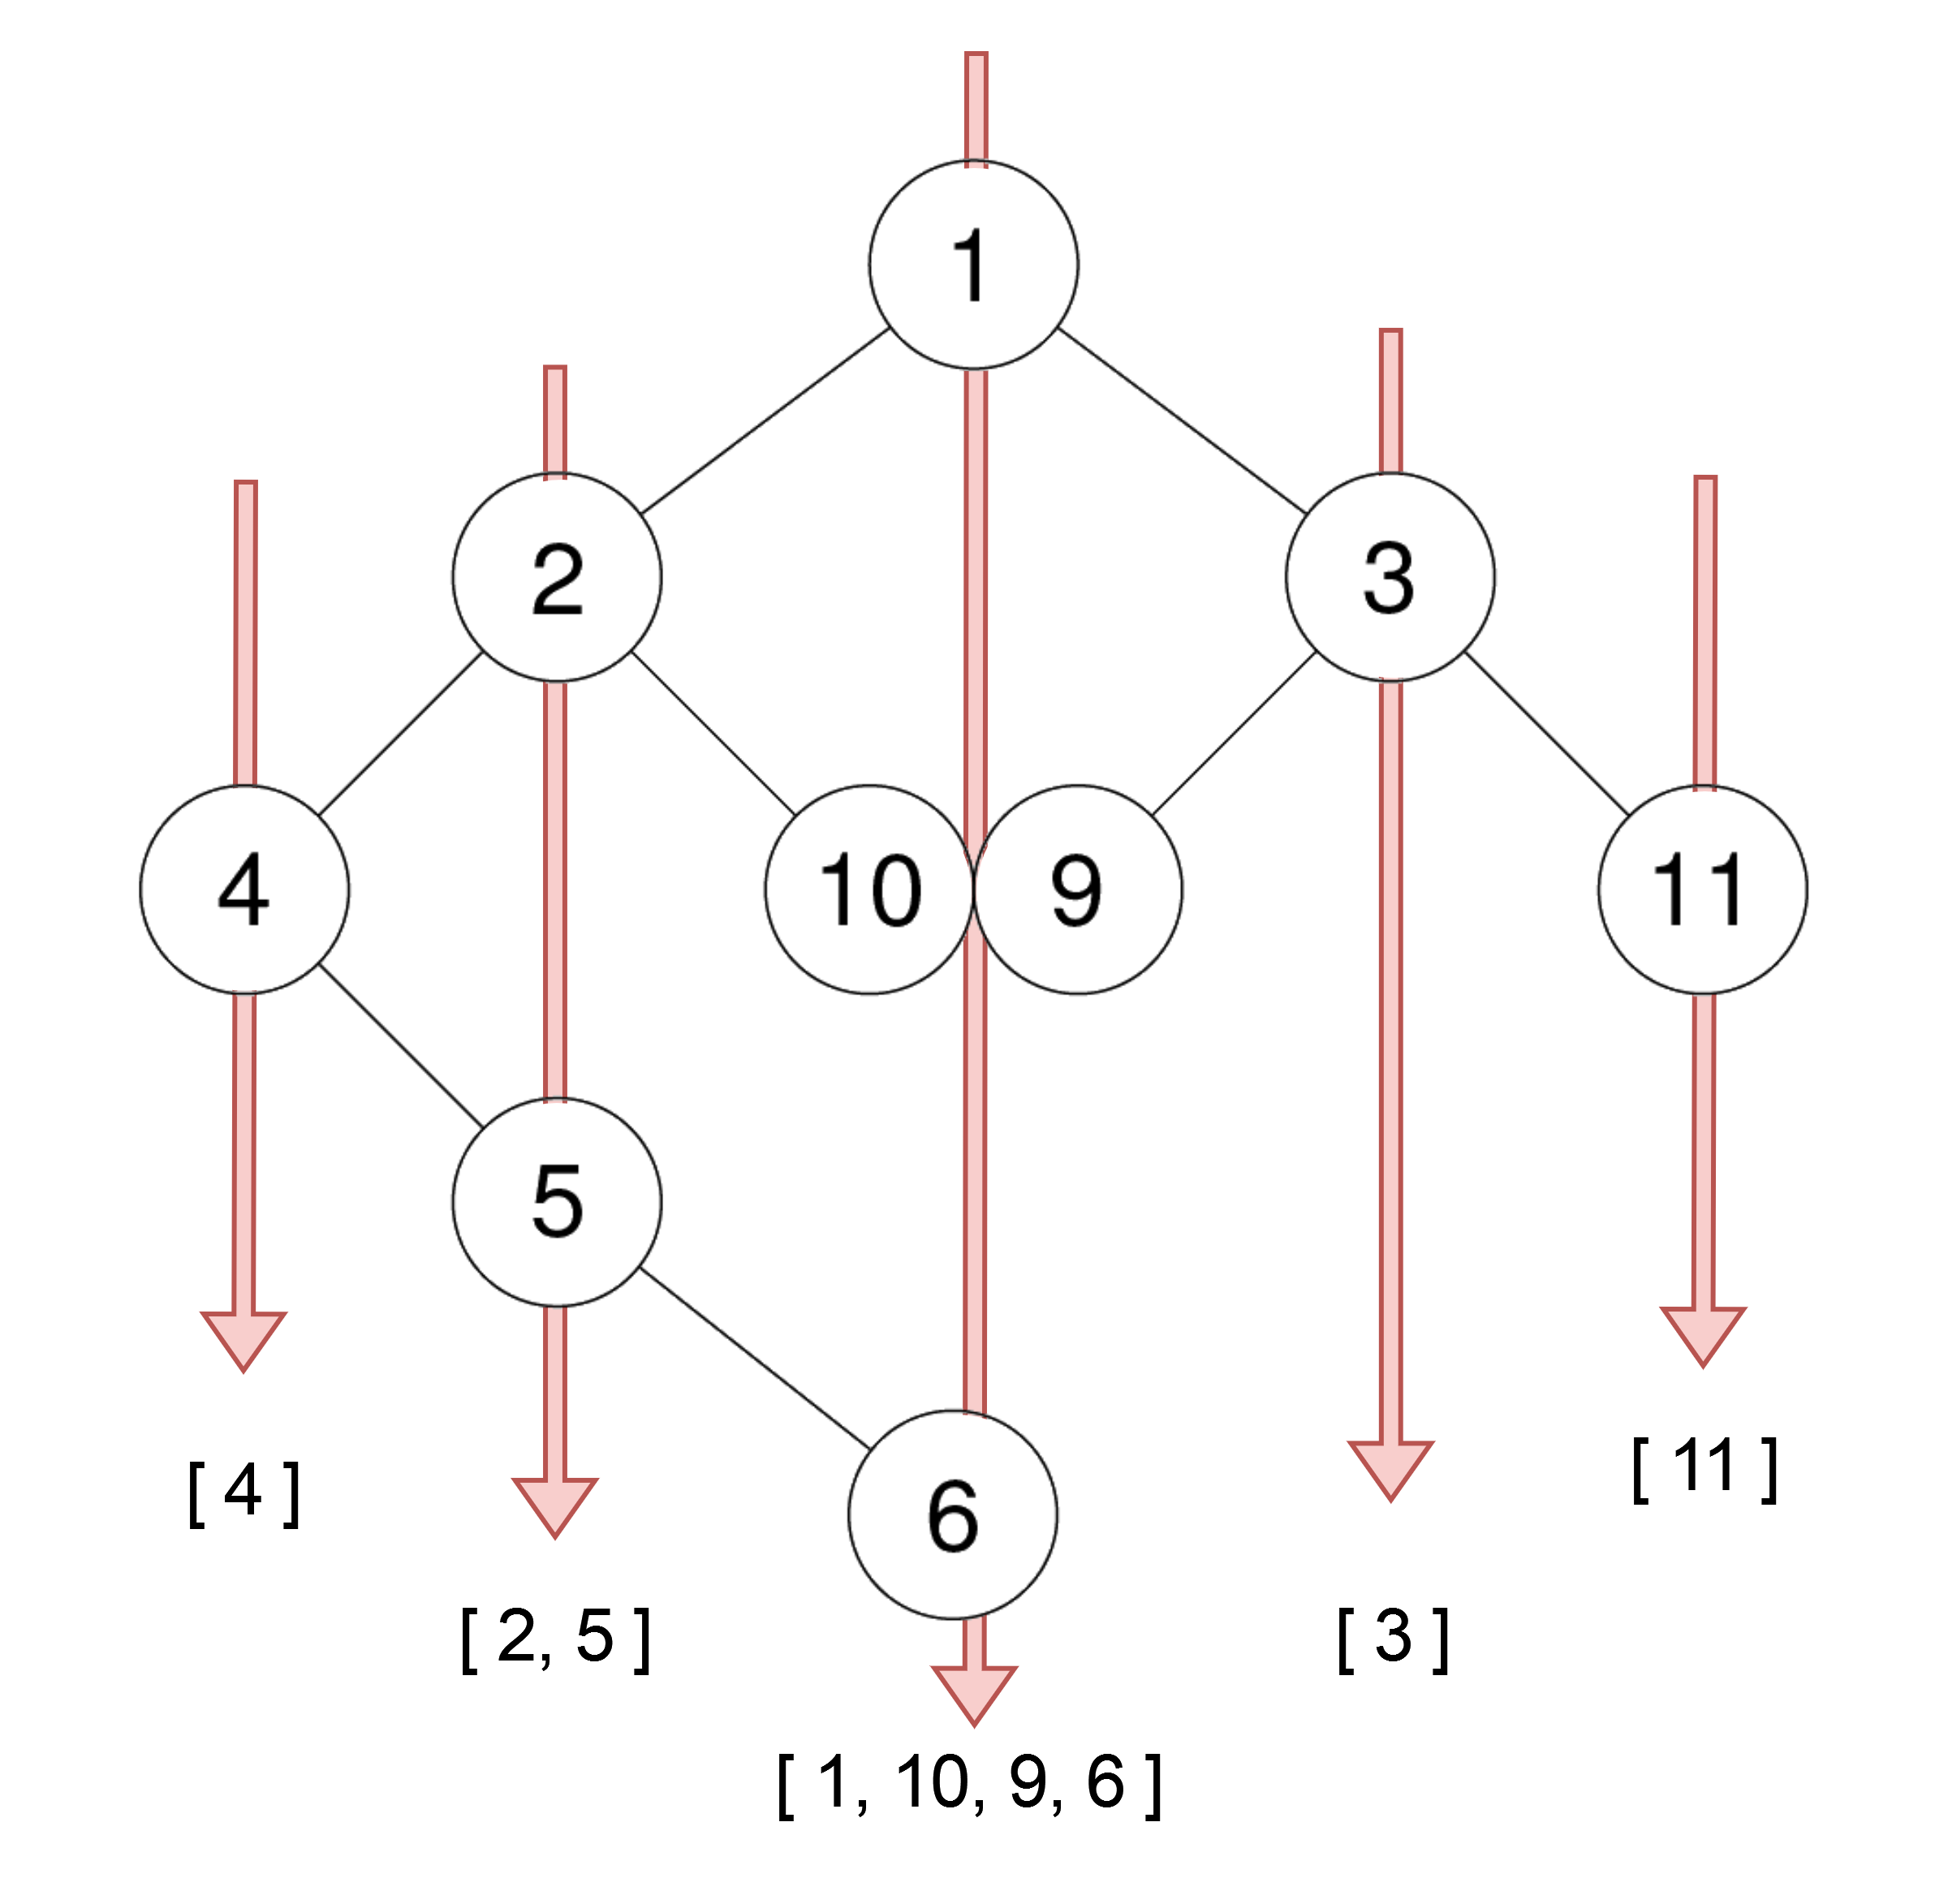

Input: root = [1,2,3,4,10,9,11,null,5,null,null,null,null,null,null,null,6]
Output: [[4],[2,5],[1,10,9,6],[3],[11]]


Step-by-Step Anaysis

1. What does “vertical order” mean?
    - Imagine drawing vertical lines through the tree 
    - Each node belongs to a "column" based on its horizontal distance from the root:
        * Root -> column 0 
        * Left Child -> column - 1
        * Right Child -> column + 1 

Then we group nodes by column and output columns from leftmost → rightmost.

Important Note: 
    If two nodes are in the same row and column → order should be left → right

This is the key reason we use BFS (level order traversal) instead of DFS.

Optimal Approach (BFS)
Why BFS?
    - Ensures top-to-bottom order 
    - naturally preserves left-to-right order 

Complexity: 
Tome O(n) 
Space O(n)

❓ Why not DFS?
DFS breaks left-to-right order at same row
Example:
Right subtree node may appear before left subtree node incorrectly

👉 BFS guarantees correct ordering without extra sorting

In [ ]:
from collections import defaultdict, deque

class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def verticalOrder(self, root):
        if not root:
            return []
        
        column_table = defaultdict(list)
        queue = deque([(root, 0)])
        
        min_col = max_col = 0
        
        while queue:
            node, col = queue.popleft()
            
            if node:
                column_table[col].append(node.val)
                
                min_col = min(min_col, col)
                max_col = max(max_col, col)
                
                queue.append((node.left, col - 1))
                queue.append((node.right, col + 1))
        
        result = []
        for col in range(min_col, max_col + 1):
            result.append(column_table[col])
        
        return result

# Build tree
root = TreeNode(3)
root.left = TreeNode(9)
root.right = TreeNode(20)
root.right.left = TreeNode(15)
root.right.right = TreeNode(7)

# Run
sol = Solution()
print(sol.verticalOrder(root))